An example of Gillespie for one reaction, corresponding to 

$$\frac{dX}{dt} = k -X/\tau_X $$

In [ ]:
import random as random
import numpy as np
import matplotlib.pyplot as plt


#Parameters
k=5 #rate of creation
tauX = 2 #decay time


# 
tmax = 40

# SOLUTION 1

# 0. Set initial conditions
nX = 1
t = 0

#make lists for saving the values
Xt = [nX]
tt = [t]

#run Gillspie 
while t <= tmax:
    #1. update rates
    prod_X = k #creation rate, 
    deg_X = nX/tauX #removal rate
    
    #total rate,
    total_rate = prod_X + deg_X
    
    #2. time to next reaction
    rn1 = random.random()
    tau = -1/total_rate*np.log(rn1) #the time to next reaction , from exponential distribution, rn = 1-exp(-total_rate*tau), or because 1-rn is also a rn, rn = exp(-total_rate*tau)
    #3. find wich reaction (production or degradation) will take place
    rn2  = random.random()
    if(rn2 < prod_X/total_rate):
        nX = nX + 1 # creation reaction
    else:
        nX = nX - 1 #otherwise do removal reaction
           
    # 4. advance in time with tau
    t = t + tau
    # save values for plotting
    Xt.append(nX)
    tt.append(t)
 
       


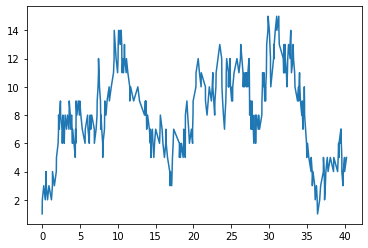

In [24]:
plt.plot(tt,Xt)

### An alternative solution that can be easy generalized to loops if have many reactions as in e.g. Oosawa model

In [25]:
# SOUTION 2, that can be easy generalized to loops if have many reactions as in e.g. Oosawa model



# 0. Set initial conditions
nX = 1
t = 0

#make lists for saving the values
Xt = [nX]
tt = [t]

#run Gillspie 
while t <= tmax:
    #1. update rates
    prod_X = k #creation rate
    deg_X = nX/tauX #removal rate
    
    #total rate,
    total_rate = prod_X + deg_X
    
    #2. time to next reaction
    rn1 = random.random()
    tau = -1/total_rate*np.log(rn1) #the time to next reaction , from exponential distribution, rn = 1-exp(-total_rate*tau), or because 1-rn is also a rn, rn = exp(-total_rate*tau)
    #3. find wich reaction (production or degradation) will take place
    rn2  = random.random()
    done = False #This variable will be used to track 
    
    if(rn2 < prod_X/total_rate):
        nX = nX + 1
        done = True
    
    if (not done):
        if (rn2 < (prod_X + deg_X)/total_rate): # here checking if degradation reaction should happen. Could have just done with else in previous if sttement
            nX = nX - 1
            done = True
    #4. advance in time with tau
    t = t + tau
    # save values for plotting
    Xt.append(nX)
    tt.append(t)
 
    